# Bài 2 / 2.4. Analyzing the data

## Mục lục 2.4

1. [**Mô tả về dữ liệu**](#ch1) <br>
    1.1. [Sợ lược về bộ dữ liệu data_khaosat.csv](#sec1-1) <br>
    1.2. [Sợ lược về bộ dữ liệu data_cauhoi.csv](#sec1-2) <br>
<br>
2. [**Thực hiện các thông kê căn bản**](#ch2) <br>
    2.1. [Các ngành học của sinh viên khảo sát](#sec2-1) <br>
    2.2. [Khóa của các sinh viên khảo sát](#sec2-2) <br>
    2.3. [Giới tính của các sinh viên khảo sát](#sec2-3) <br>
    2.4. [Các câu trả lời đánh giá của sinh viên khảo sát liên quan đến CSVC (cơ sở vật chất) ở IUH](#sec2-4) <br>
    2.5. [Các câu trả lời đánh giá của sinh viên khảo sát liên quan đến GV (giảng viên) ở IUH](#sec2-5) <br>
    2.6. [Tổng số lượng câu trả lời đánh giácủa sinh viên cho toàn bộ bảng khảo sát](#sec2-7) <br>
<br>
3. [**Mối tương quan giữa các câu hỏi khảo sát và kết quả**](#ch3) <br>
<br>
4. [**Xác định các yếu tố quan trọng ảnh hưởng đến kết quả**](#ch4) <br>
    4.1. [Khóa của sinh viên ảnh hưởng đến các kết quả khảo sát](#sec4-1) <br>

5. [**Trực quan hóa dữ liệu và kết quả**](#ch5) <br>
    5.1. [Trực quan hóa dữ liệu khảo sát](#sec5-1) <br>
    5.2. [Trực quan hóa kết quả khảo sát](#sec5-1) <br>

## Import các thư viện cần thiết để phân tích dữ liệu

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

<a id='ch1'></a>
## 1. Mô tả về dữ liệu

<a id='sec1-1'></a>
### 1.1. Sợ lược về bộ dữ liệu data_khaosat.csv

Mô tả các thuộc tính của bộ dữ liệu:
- `Tên`: Họ tên của sinh viên thực hiện khảo sát
- `Ngành`: Ngành học của sinh viên
- `Khóa`: Khóa học của sinh viên
- `Giới tính`: Giới tính của sinh viên
- `CSVC (1)` : Đánh giá cực tích cực về cơ sở vật chất của trường
- `CSVC (1)` : Đánh giá tích cực về cơ sở vật chất của trường
- `CSVC (3)` : Đánh giá trung lập về cơ sở vật chất của trường
- `CSVC (4)` : Đánh giá tiêu cực về cơ sở vật chất của trường
- `CSVC (5)` : Đánh giá cực tiêu cực về cơ sở vật chất của trường
- `GV (1)` : Đánh giá cực tích cực về giảng viên của trường
- `GV (1)` : Đánh giá tích cực về giảng viên của trường
- `GV (3)` : Đánh giá trung lập về giảng viên của trường
- `GV (4)` : Đánh giá tiêu cực về giảng viên của trường
- `GV (5)` : Đánh giá cực tiêu cực về giảng viên của trường
- `CTDT (1)` : Đánh giá text về chương trình đào tạo của trường
- `CTDT (2)` : Đánh giá text  về chương trình đào tạo của trường
- `CTDT ()` : Đánh giá text về chương trình đào tạo của trường

#### 1.1.1. Đọc và in ra 10 dòng đầu của bộ dữ liệu

In [ ]:
df_khaosat = pd.read_csv('data_khaosat.csv', encoding='utf-8')
df_khaosat.head(10)

,Tên,Ngành,Khóa,Giới tính,CSVC (1),CSVC (2),CSVC (3),CSVC(4),CSVC(5),GV (1),GV(2),GV(3),GV(4),GV(5),CTDT(1),CTDT(2),CTDT()
0,Nguyễn Thanh Hưng,Công nghệ kỹ thuật máy tính,16,Nam,4,0,0,0,0,3,0,0,0,0,Tương đối,"Khá ổn, cải thiện lí thuyết",Có
1,Trần Phương Linh,Kỹ thuật phần mềm,16,Nam,2,0,0,2,0,1,0,2,0,0,Có,"Khá ổn, cải thiện lí thuyết",Có
2,Lê Minh Đức,Kỹ thuật cơ khí,16,Nam,0,1,2,0,1,0,2,1,0,0,Có,"Khá ổn, cải thiện lí thuyết",Không
3,Nguyễn Thu Na,Thiết kế thời trang,18,Nữ,0,4,0,0,0,0,0,3,0,0,Tương đối,Tạm ổn,Có
4,Nguyễn Minh Nhật,Khoa học máy tính,16,Nam,4,0,0,0,0,3,0,0,0,0,Tương đối,"Khá ổn, cải thiện lí thuyết",Có
5,Búi Bích Ngọc,Công nghệ thực phẩm,19,Nữ,0,0,1,2,1,0,0,1,2,0,Chưa ổn,Nên nâng cao thực thành,Không
6,Ngô Đình Khang,Kỹ thuật phần mềm,19,Nam,4,0,0,0,0,3,0,0,0,0,Có,"Tốt, không cần cải thiện",Có
7,Huỳnh Nhật Nam,Cơ - điện tử,16,Nam,0,0,0,2,2,0,0,0,2,1,Đáp ứng không nhiều,"Tạm ổn, cần cai thiện",Có
8,Phạm Tú Trinh,Công nghệ may,18,Nữ,0,0,4,0,0,0,3,0,0,0,Có,"Tốt, không cần cải thiện",Có
9,Nguyễn Tấn Tài,Kỹ thuật phần mềm,17,Nam,0,2,2,0,0,0,0,2,1,0,Tương đối,Ổn,Có


#### 1.1.2. Kích thước của bộ dữ liệu

In [ ]:
print(df_khaosat.shape)
print("Dữ liệu có {} dòng và {} thuộc tính đã mô tả ở trên".format(df_khaosat.shape[0], df_khaosat.shape[1]))

(50, 17)
Dữ liệu có 50 dòng và 17 thuộc tính đã mô tả ở trên


#### 1.1.4. Thông tin về các thuộc tính của bộ dữ liệu

In [ ]:
df_khaosat.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Tên        50 non-null     object
 1   Ngành      50 non-null     object
 2   Khóa       50 non-null     int64 
 3   Giới tính  50 non-null     object
 4   CSVC (1)   50 non-null     int64 
 5   CSVC (2)   50 non-null     int64 
 6   CSVC (3)   50 non-null     int64 
 7   CSVC(4)    50 non-null     int64 
 8   CSVC(5)    50 non-null     int64 
 9   GV (1)     50 non-null     int64 
 10  GV(2)      50 non-null     int64 
 11  GV(3)      50 non-null     int64 
 12  GV(4)      50 non-null     int64 
 13  GV(5)      50 non-null     int64 
 14  CTDT(1)    50 non-null     object
 15  CTDT(2)    50 non-null     object
 16  CTDT()     50 non-null     object
dtypes: int64(11), object(6)
memory usage: 6.8+ KB


#### 1.1.5. Xem các giá trị phân biệt trong từng thuộc tính

In [ ]:
df_khaosat.nunique()

Tên          49
Ngành        22
Khóa          4
Giới tính     2
CSVC (1)      5
CSVC (2)      5
CSVC (3)      4
CSVC(4)       3
CSVC(5)       4
GV (1)        4
GV(2)         4
GV(3)         4
GV(4)         4
GV(5)         3
CTDT(1)      14
CTDT(2)      23
CTDT()        4
dtype: int64

<a id='sec1-1'></a>
### 1.2. Sợ lược về bộ dữ liệu data_cauhoi.csv

Mô tả các thuộc tính của bộ dữ liệu:
- `Câu hỏi`: Các câu hỏi đã dùng để đánh giá trong bảng khảo sát
- `Đánh giá very positive (1)`: Tổng số lượt câu trả lời đánh giá rất tích cực của câu hỏi
- `Đánh giá positive (2)`: Tổng số lượt câu trả lời đánh giá tích cực của câu hỏi
- `Đánh giá neutral  (3)`: Tổng số lượt câu trả lời đánh giá trung lập của câu hỏi
-`Đánh giá negative (4)` : Tổng số lượt câu trả lời đánh giá tiêu cực của câu hỏi
-`Đánh giá extremely negative (5)`: Tổng số lượt câu hỏi đánh giá cực kì tiêu cực

#### 1.2.1. Đọc và in ra 10 dòng đầu của bộ dữ liệu

In [ ]:
df_cauhoi = pd.read_csv('data_cauhoi.csv', encoding='utf-8')
df_cauhoi.head(10)

,Câu hỏi,Đánh giá very positive (1),Đánh giá positive (2),Đánh giá neutral (3),Đánh giá negative (4),Đánh giá extremely negative (5)
0,Bạn có thấy cơ sở vật chất tại IUH đáp ứng đủ ...,16,12,7,8,7
1,Bạn có thấy thoải mái khi học tập và nghỉ ngơi...,11,12,6,10,11
2,Trường có đáp ứng đủ ngu cầu của sinh viên về ...,12,12,16,4,6
3,Trường đã đám bảo được sự ổn định của hệ thống...,10,13,10,9,8
4,Các giảng viên có sử dụng phương pháp giảng dạ...,16,9,10,7,8
5,Giảng viên có thường xuyên hỗ trợ sinh viên ng...,13,17,10,10,0
6,Giảng viên có cung cấp đầy đủ tài liệu và nguồ...,19,22,9,0,0


#### 1.2.2. Kích thước của bộ dữ liệu

In [ ]:
print(df_cauhoi.shape)
print("Dữ liệu có {} dòng và {} thuộc tính đã mô tả ở trên".format(df_cauhoi.shape[0], df_cauhoi.shape[1]))

(7, 6)
Dữ liệu có 7 dòng và 6 thuộc tính đã mô tả ở trên


#### 1.2.3. Thông tin về các thuộc tính của bộ dữ liệu

In [ ]:
df_cauhoi.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7 entries, 0 to 6
Data columns (total 6 columns):
 #   Column                           Non-Null Count  Dtype 
---  ------                           --------------  ----- 
 0   Câu hỏi                          7 non-null      object
 1   Đánh giá very positive (1)       7 non-null      int64 
 2   Đánh giá positive (2)            7 non-null      int64 
 3   Đánh giá neutral (3)             7 non-null      int64 
 4   Đánh giá negative (4)            7 non-null      int64 
 5   Đánh giá extremely negative (5)  7 non-null      int64 
dtypes: int64(5), object(1)
memory usage: 464.0+ bytes


#### 1.2.4. Xem các giá trị phân biệt trong từng thuộc tính

In [ ]:
df_cauhoi.nunique()

Câu hỏi                            7
Đánh giá very positive (1)         6
Đánh giá positive (2)              5
Đánh giá neutral (3)               5
Đánh giá negative (4)              6
Đánh giá extremely negative (5)    5
dtype: int64

#### 1.2.5. Tách các câu hỏi trong bộ dữ liệu data_cauhoi.csv thành các câu hỏi riêng biệt theo chủ đề đã khảo sát để dễ dàng truy xuất và phân tích dữ liệu

In [ ]:
df_cauhoi_csvc = df_cauhoi.iloc[0:4]
df_cauhoi_gv = df_cauhoi.iloc[4:7]

In [ ]:
df_cauhoi_csvc

,Câu hỏi,Đánh giá very positive (1),Đánh giá positive (2),Đánh giá neutral (3),Đánh giá negative (4),Đánh giá extremely negative (5)
0,Bạn có thấy cơ sở vật chất tại IUH đáp ứng đủ ...,16,12,7,8,7
1,Bạn có thấy thoải mái khi học tập và nghỉ ngơi...,11,12,6,10,11
2,Trường có đáp ứng đủ ngu cầu của sinh viên về ...,12,12,16,4,6
3,Trường đã đám bảo được sự ổn định của hệ thống...,10,13,10,9,8


In [ ]:
df_cauhoi_gv

,Câu hỏi,Đánh giá very positive (1),Đánh giá positive (2),Đánh giá neutral (3),Đánh giá negative (4),Đánh giá extremely negative (5)
4,Các giảng viên có sử dụng phương pháp giảng dạ...,16,9,10,7,8
5,Giảng viên có thường xuyên hỗ trợ sinh viên ng...,13,17,10,10,0
6,Giảng viên có cung cấp đầy đủ tài liệu và nguồ...,19,22,9,0,0


<a id='ch2'></a>
## 2. Thực hiện các thống kê căn bản

In [ ]:
def thong_ke_thuoc_tinh(data, att):

    print('Thống kê số lượng: ')
    print(data[att].value_counts())

    print('\n\nTỷ lệ: ')
    tyle = round((data[att].value_counts() / data[att].count()) * 100, 2)
    print(tyle)

<a id='sec2-1'></a>
### 2.1. Các ngành học của sinh viên khảo sát

In [ ]:
df_khaosat["Ngành"].value_counts()

Ngành
Kỹ thuật phần mềm              10
Khoa học máy tính               5
Kỹ thuật cơ khí                 4
Quản trị kinh doanh             4
Công nghệ thực phẩm             3
Khoa học dữ liệu                3
Du lịch - khách sạn             2
Thiết kế thời trang             2
Công nghệ may                   2
Điều khiển tự động              2
Kỹ thuật ô tô                   2
Kỹ thuật máy tính               1
Công nghệ thông tin             1
Công nghệ ô tô                  1
Công nghệ sinh học              1
Công nghệ kỹ thuật máy tính     1
Hệ thống thông tin              1
Kỹ thuật điện tử                1
Chế tạo máy                     1
Khoa học máy tinh               1
Cơ - điện tử                    1
Quản lý đất đai                 1
Name: count, dtype: int64

<a id='sec2-2'></a>
### 2.2. Khóa của các sinh viên khảo sát

In [ ]:
thong_ke_thuoc_tinh(df_khaosat, 'Khóa')

Thống kê số lượng: 
Khóa
16    23
18    10
19     9
17     8
Name: count, dtype: int64


Tỷ lệ: 
Khóa
16    46.0
18    20.0
19    18.0
17    16.0
Name: count, dtype: float64


<a id='sec2-3'></a>
### 2.3. Giới tính của các sinh viên khảo sát

In [ ]:
thong_ke_thuoc_tinh(df_khaosat, 'Giới tính')

Thống kê số lượng: 
Giới tính
Nam    37
Nữ     13
Name: count, dtype: int64


Tỷ lệ: 
Giới tính
Nam    74.0
Nữ     26.0
Name: count, dtype: float64


<a id='sec2-4'></a>
### 2.4. Các câu trả lời đánh giá của sinh viên khảo sát liên quan đến CSVC (cơ sở vật chất) ở IUH

In [ ]:
print('Các lượt đánh giá về chất lượng cơ sở vật chất của trường là: \n', df_khaosat['CSVC (1)'].sum(), 'lượt cực tích cực, ', df_khaosat['CSVC (2)'].sum(), 'lượt tích cực và ', df_khaosat['CSVC (3)'].sum(), 'lượt trung lập',df_khaosat['CSVC(4)'].sum(), 'lượt tiêu cực',df_khaosat['CSVC(5)'].sum(), 'lượt cực tiêu cực' )

Các lượt đánh giá về chất lượng cơ sở vật chất của trường là: 
 58 lượt cực tích cực,  51 lượt tích cực và  40 lượt trung lập 24 lượt tiêu cực 28 lượt cực tiêu cực


In [ ]:
sum_CSVC = df_khaosat['CSVC (1)'].sum() + df_khaosat['CSVC (2)'].sum() + df_khaosat['CSVC (3)'].sum() + df_khaosat['CSVC(4)'].sum() + df_khaosat['CSVC(5)'].sum()
print('Tỷ lệ lượt đánh giá cực tích cực: ', round((df_khaosat['CSVC (1)'].sum() / sum_CSVC) * 100, 2), '%')
print('Tỷ lệ lượt đánh giá tích cực: ', round((df_khaosat['CSVC (2)'].sum() / sum_CSVC) * 100, 2), '%')
print('Tỷ lệ lượt đánh giá trung lập: ', round((df_khaosat['CSVC (3)'].sum() / sum_CSVC) * 100, 2), '%')
print('Tỷ lệ lượt đánh giá tiêu cực: ', round((df_khaosat['CSVC(4)'].sum() / sum_CSVC) * 100, 2), '%')
print('Tỷ lệ lượt đánh cực tiêu cực: ', round((df_khaosat['CSVC(5)'].sum() / sum_CSVC) * 100, 2), '%')

Tỷ lệ lượt đánh giá cực tích cực:  28.86 %
Tỷ lệ lượt đánh giá tích cực:  25.37 %
Tỷ lệ lượt đánh giá trung lập:  19.9 %
Tỷ lệ lượt đánh giá tiêu cực:  11.94 %
Tỷ lệ lượt đánh cực tiêu cực:  13.93 %


#### 2.4.1. Các câu hỏi lượt trả lời đánh giá cực tích cực (1) nhiều nhất

In [ ]:
grouped = df_cauhoi_csvc.groupby(['Câu hỏi'])['Đánh giá very positive (1)'].mean()
top_3_very_positive = grouped.nlargest(3)

print('Top 3 câu hỏi có lượt trả lời đánh giá very positive (1) nhiều nhất là: ')
for cau_hoi, dg_very_positive in top_3_very_positive.items():
    print(f'- {cau_hoi}: \n{dg_very_positive} lượt trả lời đánh giá cực tích cực\n')

Top 3 câu hỏi có lượt trả lời đánh giá very positive (1) nhiều nhất là: 
- Bạn có thấy cơ sở vật chất tại IUH đáp ứng đủ nhu cầu học tập của bạn không?: 
16.0 lượt trả lời đánh giá cực tích cực

- Trường có đáp ứng đủ ngu cầu của sinh viên về thiết bị và trang thiết bị trong phòng học không?: 
12.0 lượt trả lời đánh giá cực tích cực

- Bạn có thấy thoải mái khi học tập và nghỉ ngơi tại các khuôn viên của trường không?: 
11.0 lượt trả lời đánh giá cực tích cực



#### 2.4.2. Các câu hỏi có lượt trả lời đánh giá tích cực (2) nhiều nhất

In [ ]:
grouped = df_cauhoi_csvc.groupby(['Câu hỏi'])['Đánh giá positive (2)'].mean()
top_3_positive = grouped.nlargest(3)

print('Top 3 câu hỏi có lượt trả lời đánh giá positive (2) nhiều nhất là: ')
for cau_hoi, dg_positive in top_3_positive.items():
    print(f'- {cau_hoi}: \n{dg_positive} lượt trả lời đánh giá tích cực\n')

Top 3 câu hỏi có lượt trả lời đánh giá positive (2) nhiều nhất là: 
- Trường đã đám bảo được sự ổn định của hệ thống mạng trong các tòa nhà trên khuôn viên trường chưa?: 
13.0 lượt trả lời đánh giá tích cực

- Bạn có thấy cơ sở vật chất tại IUH đáp ứng đủ nhu cầu học tập của bạn không?: 
12.0 lượt trả lời đánh giá tích cực

- Bạn có thấy thoải mái khi học tập và nghỉ ngơi tại các khuôn viên của trường không?: 
12.0 lượt trả lời đánh giá tích cực



#### 2.4.3. Các câu hỏi có lượt trả lời đánh giá trung lập (3) nhiều nhất

In [ ]:
grouped = df_cauhoi_csvc.groupby(['Câu hỏi'])['Đánh giá neutral (3)'].mean()
top_3_neutral = grouped.nlargest(3)

print('Top 3 câu hỏi có lượt trả lời đánh giá neutral (3) nhiều nhất là: ')
for cau_hoi, dg_neutral in top_3_neutral.items():
    print(f'- {cau_hoi}: \n{dg_neutral} lượt trả lời đánh giá trung lập\n')

Top 3 câu hỏi có lượt trả lời đánh giá neutral (3) nhiều nhất là: 
- Trường có đáp ứng đủ ngu cầu của sinh viên về thiết bị và trang thiết bị trong phòng học không?: 
16.0 lượt trả lời đánh giá trung lập

- Trường đã đám bảo được sự ổn định của hệ thống mạng trong các tòa nhà trên khuôn viên trường chưa?: 
10.0 lượt trả lời đánh giá trung lập

- Bạn có thấy cơ sở vật chất tại IUH đáp ứng đủ nhu cầu học tập của bạn không?: 
7.0 lượt trả lời đánh giá trung lập



#### 2.4.4. Các câu hỏi có lượt trả lời đánh giá tiêu cực (4) nhiều nhất

In [ ]:
grouped = df_cauhoi_csvc.groupby(['Câu hỏi'])['Đánh giá negative (4)'].mean()
top_3_negative = grouped.nlargest(3)

print('Top 3 câu hỏi có lượt trả lời đánh giá negative (4) nhiều nhất là: ')
for cau_hoi, dg_negative in top_3_negative.items():
    print(f'- {cau_hoi}: \n{dg_negative} lượt trả lời đánh giá tiêu cực\n')

Top 3 câu hỏi có lượt trả lời đánh giá negative (4) nhiều nhất là: 
- Bạn có thấy thoải mái khi học tập và nghỉ ngơi tại các khuôn viên của trường không?: 
10.0 lượt trả lời đánh giá tiêu cực

- Trường đã đám bảo được sự ổn định của hệ thống mạng trong các tòa nhà trên khuôn viên trường chưa?: 
9.0 lượt trả lời đánh giá tiêu cực

- Bạn có thấy cơ sở vật chất tại IUH đáp ứng đủ nhu cầu học tập của bạn không?: 
8.0 lượt trả lời đánh giá tiêu cực



#### 2.4.5. Các câu hỏi lượt trả lời đánh giá cự kì tiêu cực (5) nhiều nhất

In [ ]:
grouped = df_cauhoi_csvc.groupby(['Câu hỏi'])['Đánh giá extremely negative (5)'].mean()
top_3_extremely_negative = grouped.nlargest(3)

print('Top 3 câu hỏi có lượt trả lời Đánh giá extremely negative (5) nhiều nhất là: ')
for cau_hoi, dg_extremely_negative in top_3_extremely_negative.items():
    print(f'- {cau_hoi}: \n{dg_extremely_negative} lượt trả lời đánh giá cực kì tiêu cực\n')

Top 3 câu hỏi có lượt trả lời Đánh giá extremely negative (5) nhiều nhất là: 
- Bạn có thấy thoải mái khi học tập và nghỉ ngơi tại các khuôn viên của trường không?: 
11.0 lượt trả lời đánh giá cực kì tiêu cực

- Trường đã đám bảo được sự ổn định của hệ thống mạng trong các tòa nhà trên khuôn viên trường chưa?: 
8.0 lượt trả lời đánh giá cực kì tiêu cực

- Bạn có thấy cơ sở vật chất tại IUH đáp ứng đủ nhu cầu học tập của bạn không?: 
7.0 lượt trả lời đánh giá cực kì tiêu cực



<a id='sec2-5'></a>
### 2.5. Các câu trả lời đánh giá của sinh viên khảo sát liên quan đến GV (giảng viên) ở IUH

In [ ]:
print('Các lượt đánh giá về giảng viên của trường là: \n', df_khaosat['GV (1)'].sum(), 'lượt cực tích cực,', df_khaosat['GV(2)'].sum(), 'lượt tích cực, ', df_khaosat['GV(3)'].sum(), 'lượt trung lập và ', df_khaosat['GV(4)'].sum(), 'lượt tiêu cực, ', df_khaosat['GV(5)'].sum(), 'lượt cực tiêu cực')

Các lượt đánh giá về giảng viên của trường là: 
 39 lượt cực tích cực, 47 lượt tích cực,  28 lượt trung lập và  23 lượt tiêu cực,  12 lượt cực tiêu cực


In [ ]:
sum_GV = df_khaosat['GV (1)'].sum() + df_khaosat['GV(2)'].sum() + df_khaosat['GV(3)'].sum() + df_khaosat['GV(4)'].sum() + df_khaosat['GV(5)'].sum()
print('Tỷ lệ lượt đánh giá cực tích cực: ', round((df_khaosat['GV (1)'].sum() / sum_GV) * 100, 2), '%')
print('Tỷ lệ lượt đánh giá tích cực: ', round((df_khaosat['GV(2)'].sum() / sum_GV) * 100, 2), '%')
print('Tỷ lệ lượt đánh giá trung lập: ', round((df_khaosat['GV(3)'].sum() / sum_GV) * 100, 2), '%')
print('Tỷ lệ lượt đánh giá tiêu cực: ', round((df_khaosat['GV(4)'].sum() / sum_GV) * 100, 2), '%')
print('Tỷ lệ lượt đánh giá cực tiêu cực: ', round((df_khaosat['GV(5)'].sum() / sum_GV) * 100, 2), '%')

Tỷ lệ lượt đánh giá cực tích cực:  26.17 %
Tỷ lệ lượt đánh giá tích cực:  31.54 %
Tỷ lệ lượt đánh giá trung lập:  18.79 %
Tỷ lệ lượt đánh giá tiêu cực:  15.44 %
Tỷ lệ lượt đánh giá cực tiêu cực:  8.05 %


#### 2.5.1. Các câu hỏi lượt trả lời đánh giá cực tích cực (1) nhiều nhất

In [ ]:
grouped = df_cauhoi_gv.groupby(['Câu hỏi'])['Đánh giá very positive (1)'].mean()
top_3_very_positive = grouped.nlargest(3)

print('Top 3 câu hỏi có lượt trả lời đánh giá very positive (1) nhiều nhất là: ')
for cau_hoi, dg_very_positive in top_3_very_positive.items():
    print(f'- {cau_hoi}: \n{dg_very_positive} lượt trả lời đánh giá cực tích cực\n')

Top 3 câu hỏi có lượt trả lời đánh giá very positive (1) nhiều nhất là: 
- Giảng viên có cung cấp đầy đủ tài liệu và nguồn tài liệu tham khảo cho sinh viên?: 
19.0 lượt trả lời đánh giá cực tích cực

- Các giảng viên có sử dụng phương pháp giảng dạy phù hợp và hiệu quả không?: 
16.0 lượt trả lời đánh giá cực tích cực

- Giảng viên có thường xuyên hỗ trợ sinh viên ngoài giờ lên lớp hay không?: 
13.0 lượt trả lời đánh giá cực tích cực



#### 2.5.2. Các câu hỏi có lượt trả lời đánh giá tích cực (2) nhiều nhất

In [ ]:
grouped = df_cauhoi_gv.groupby(['Câu hỏi'])['Đánh giá positive (2)'].mean()
top_3_positive = grouped.nlargest(3)

print('Top 3 câu hỏi có lượt trả lời đánh giá positive (2) nhiều nhất là: ')
for cau_hoi, dg_positive in top_3_positive.items():
    print(f'- {cau_hoi}: \n{dg_positive} lượt trả lời đánh giá tích cực\n')

Top 3 câu hỏi có lượt trả lời đánh giá positive (2) nhiều nhất là: 
- Giảng viên có cung cấp đầy đủ tài liệu và nguồn tài liệu tham khảo cho sinh viên?: 
22.0 lượt trả lời đánh giá tích cực

- Giảng viên có thường xuyên hỗ trợ sinh viên ngoài giờ lên lớp hay không?: 
17.0 lượt trả lời đánh giá tích cực

- Các giảng viên có sử dụng phương pháp giảng dạy phù hợp và hiệu quả không?: 
9.0 lượt trả lời đánh giá tích cực



#### 2.5.2. Các câu hỏi có lượt trả lời đánh giá trung lập (0) nhiều nhất

In [ ]:
grouped = df_cauhoi_gv.groupby(['Câu hỏi'])['Đánh giá neutral (3)'].mean()
top_3_neutral = grouped.nlargest(3)

print('Top 3 câu hỏi có lượt trả lời đánh giá neutral (3) nhiều nhất là: ')
for cau_hoi, dg_neutral in top_3_neutral.items():
    print(f'- {cau_hoi}: \n{dg_neutral} lượt trả lời đánh giá trung lập\n')

Top 3 câu hỏi có lượt trả lời đánh giá neutral (3) nhiều nhất là: 
- Các giảng viên có sử dụng phương pháp giảng dạy phù hợp và hiệu quả không?: 
10.0 lượt trả lời đánh giá trung lập

- Giảng viên có thường xuyên hỗ trợ sinh viên ngoài giờ lên lớp hay không?: 
10.0 lượt trả lời đánh giá trung lập

- Giảng viên có cung cấp đầy đủ tài liệu và nguồn tài liệu tham khảo cho sinh viên?: 
9.0 lượt trả lời đánh giá trung lập



#### 2.5.3. Các câu hỏi có lượt trả lời đánh giá tiêu cực (4) nhiều nhất

In [ ]:
grouped = df_cauhoi_gv.groupby(['Câu hỏi'])['Đánh giá negative (4)'].mean()
top_3_negative = grouped.nlargest(3)

print('Top 3 câu hỏi có lượt trả lời đánh giá negative (4) nhiều nhất là: ')
for cau_hoi, dg_negative in top_3_negative.items():
    print(f'- {cau_hoi}: \n{dg_negative} lượt trả lời đánh giá tiêu cực\n')

Top 3 câu hỏi có lượt trả lời đánh giá negative (4) nhiều nhất là: 
- Giảng viên có thường xuyên hỗ trợ sinh viên ngoài giờ lên lớp hay không?: 
10.0 lượt trả lời đánh giá tiêu cực

- Các giảng viên có sử dụng phương pháp giảng dạy phù hợp và hiệu quả không?: 
7.0 lượt trả lời đánh giá tiêu cực

- Giảng viên có cung cấp đầy đủ tài liệu và nguồn tài liệu tham khảo cho sinh viên?: 
0.0 lượt trả lời đánh giá tiêu cực



#### 2.5.3. Các câu hỏi có lượt trả lời đánh giá cực kì tiêu cực (5) nhiều nhất

In [ ]:
grouped = df_cauhoi_gv.groupby(['Câu hỏi'])['Đánh giá extremely negative (5)'].mean()
top_3_extremely_negative = grouped.nlargest(3)

print('Top 3 câu hỏi có lượt trả lời Đánh giá extremely negative (5) nhiều nhất là: ')
for cau_hoi, dg_extremely_negative in top_3_extremely_negative.items():
    print(f'- {cau_hoi}: \n{dg_extremely_negative} lượt trả lời đánh giá cực tiêu cực\n')

Top 3 câu hỏi có lượt trả lời Đánh giá extremely negative (5) nhiều nhất là: 
- Các giảng viên có sử dụng phương pháp giảng dạy phù hợp và hiệu quả không?: 
8.0 lượt trả lời đánh giá cực tiêu cực

- Giảng viên có cung cấp đầy đủ tài liệu và nguồn tài liệu tham khảo cho sinh viên?: 
0.0 lượt trả lời đánh giá cực tiêu cực

- Giảng viên có thường xuyên hỗ trợ sinh viên ngoài giờ lên lớp hay không?: 
0.0 lượt trả lời đánh giá cực tiêu cực



<a id='sec2-7'></a>
### 2.7. Tổng số lượng câu trả lời đánh giá cực tích cực (1),tích cực (2) ,trung lập (3) và tiêu cực (4), cực kì tiêu cực (5) của sinh viên cho toàn bộ bảng khảo sát

In [ ]:
tong_tich_cuc = df_khaosat['CSVC (1)'].sum() + df_khaosat['GV (1)'].sum() + df_khaosat['CTDT (1)'].sum()
tong_trung_lap = df_khaosat['CSVC (0)'].sum() + df_khaosat['GV (0)'].sum() + df_khaosat['CTDT (0)'].sum()
tong_tieu_cuc = df_khaosat['CSVC (-1)'].sum() + df_khaosat['GV (-1)'].sum() + df_khaosat['CTDT (-1)'].sum()

print('Tổng lượt trả lời đánh giá tích cực:', tong_tich_cuc)
print('Tỷ lệ lượt trả lời đánh giá tích cực chiếm:', round((tong_tich_cuc / (tong_tich_cuc + tong_trung_lap + tong_tieu_cuc)) * 100, 2), '%\n')

print('Tổng lượt trả lời đánh giá trung lập:', tong_trung_lap)
print('Tỷ lệ lượt trả lời đánh giá trung lập chiếm:', round((tong_trung_lap / (tong_tich_cuc + tong_trung_lap + tong_tieu_cuc)) * 100, 2), '%\n')

print('Tổng lượt trả lời đánh giá tiêu cực:', tong_tieu_cuc)
print('Tỷ lệ lượt trả lời đánh giá tiêu cực chiếm:', round((tong_tieu_cuc / (tong_tich_cuc + tong_trung_lap + tong_tieu_cuc)) * 100, 2), '%\n')

Tổng lượt trả lời đánh giá tích cực: 252
Tỷ lệ lượt trả lời đánh giá tích cực chiếm: 33.6 %

Tổng lượt trả lời đánh giá trung lập: 366
Tỷ lệ lượt trả lời đánh giá trung lập chiếm: 48.8 %

Tổng lượt trả lời đánh giá tiêu cực: 132
Tỷ lệ lượt trả lời đánh giá tiêu cực chiếm: 17.6 %



<a id='ch3'></a>
## 3. Mối tương quan giữa các câu hỏi khảo sát và kết quả

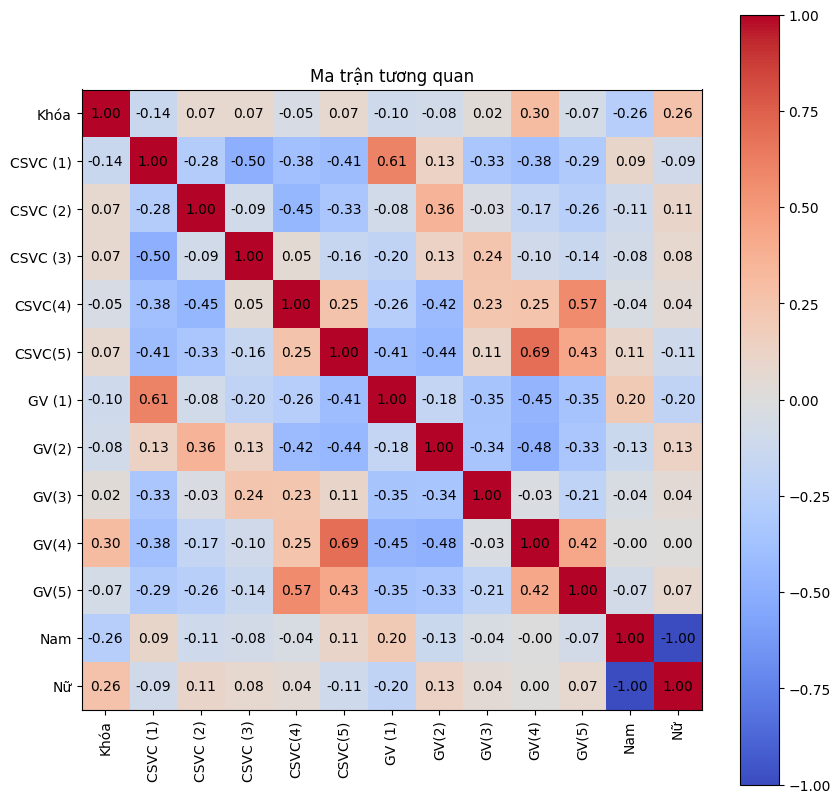

In [ ]:
# Tạo dataframe mới để không làm thay đổi dataframe gốc
df_khaosat_heatmap = pd.read_csv('data_khaosat.csv')

# Loại bỏ cột 'Tên' và 'Giới tính' từ DataFrame
df_numeric = df_khaosat_heatmap.drop(['Tên ', 'Giới tính', 'Ngành', 'CTDT(1)', 'CTDT(2)', 'CTDT()'], axis=1)

# Áp dụng mã hóa one-hot cho cột "Giới tính"
gender = pd.get_dummies(df_khaosat_heatmap['Giới tính'])

# Nối kết kết quả mã hóa one-hot với dữ liệu ban đầu
df_numeric = pd.concat([df_numeric, gender], axis=1)

# Tính ma trận tương quan giữa các biến
corr_matrix = df_numeric.corr()

# Vẽ biểu đồ heatmap của ma trận tương quan
fig, ax = plt.subplots(figsize=(10, 10))
im = ax.imshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)

# Hiển thị tên cột và dòng
ax.set_xticks(np.arange(len(corr_matrix.columns)))
ax.set_yticks(np.arange(len(corr_matrix.index)))
ax.set_xticklabels(corr_matrix.columns)
ax.set_yticklabels(corr_matrix.index)

# Xoay tên cột
plt.xticks(rotation=90)

# Thêm số liệu vào từng ô
for i in range(len(corr_matrix.index)):
    for j in range(len(corr_matrix.columns)):
        text = ax.text(j, i, "{:.2f}".format(corr_matrix.iloc[i, j]),
                       ha="center", va="center", color="black")

# Thiết lập tiêu đề và thanh màu
ax.set_title("Ma trận tương quan")
plt.colorbar(im)
plt.show()

### Một số nhận xét:
- Các cột CSVC (1), GV (1) có tương quan dương mạnh với nhau, nghĩa là những sinh viên đánh giá tích cực về cơ sở vật chất, giảng viên và chương trình đào tạo của trường thường sẽ đánh giá tích cực về các mặt này cùng một lúc.
- Tương tự, các cột CSVC (5), GV (5) cũng có tương quan dương mạnh với nhau, tức là những sinh viên đánh giá tiêu cực về các mặt này thường sẽ đánh giá tiêu cực về các mặt khác.
- Cột Nam thể hiện mối tương quan âm với cột GV (1) còn cột Nữ thể hiện mối tương quan dương với cột GV (1), cho thấy những sinh viên nam thường đánh giá tiêu cực về giảng viên, trong khi sinh viên nữ thường đánh giá tích cực về giảng viên nhiều hơn.
- Tương tự, các cột CSVC (1) tương quan âm với cột Nam, tương quan dương với Nữ, cho thấy những sinh viên nữ thường có xu hướng đánh giá tích cực nhiều hơn sinh viên nam về các câu hỏi khảo sát

<a id='ch4'></a>
## 4. Xác định các yếu tố quan trọng ảnh hưởng đến kết quả

<span style="color:red">**Dựa vào các mối tương quan đã tìm ra ở Heatmap ta kết luận được các yếu tố quan trọng ảnh hưởng đến kết quả là:** `Khóa` **và** `Giới tính` **của sinh viên khảo sát.**</span>

<a id='sec4-1'></a>
### 4.1. Khóa của sinh viên ảnh hưởng đến các kết quả khảo sát

In [ ]:
# Loại bỏ cột chuỗi khỏi DataFrame
df_numeric = df_khaosat.drop(['Tên ', 'Giới tính', 'Ngành', 'CTDT(1)', 'CTDT(2)', 'CTDT()'], axis=1)

# Tính toán giá trị trung bình cho từng nhóm 'Khóa'
mean_by_khoa = df_numeric.groupby('Khóa').mean()


<Axes: xlabel='Khóa'>

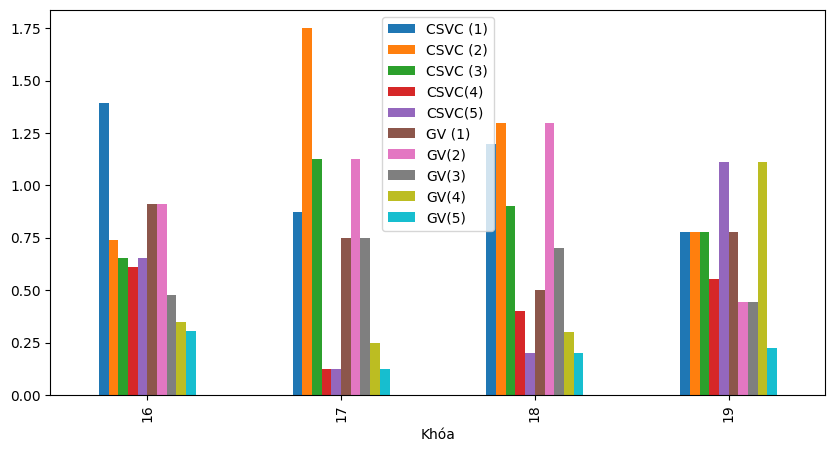

In [ ]:
mean_by_khoa.groupby(['Khóa']).mean().plot(kind='bar', figsize=(10, 5))

### Một số nhận xét
- Sinh viên các khóa đánh giá rất tốt về cơ sở vật chất và giáo viên, trong đó K17 đánh giá tích cực về csvc nhiều nhất
- Sinh viên K19 đánh giá khá đều nhau về các mục

<a id='ch5'></a>
## 5. Trực quan hóa dữ liệu và kết quả

<a id='sec5-1'></a>
### 5.1. Trực quan hóa dữ liệu khảo sát

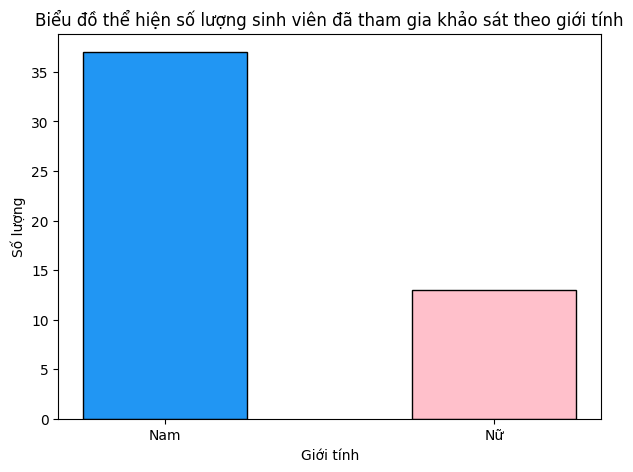

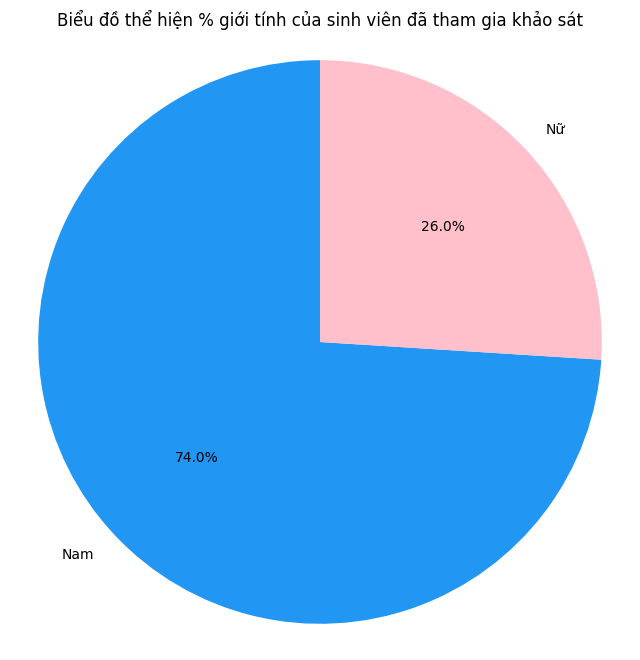

In [ ]:
gender_counts = df_khaosat['Giới tính'].value_counts()
gender_percentages = gender_counts * 100 / len(df_khaosat)

# Vẽ biểu đồ cột
plt.figure(figsize=(7, 5))
plt.bar(gender_counts.index, gender_counts, color=['#2196F3', '#ffc0cb'], width=0.5, edgecolor='black')
plt.title('Biểu đồ thể hiện số lượng sinh viên đã tham gia khảo sát theo giới tính')
plt.xlabel('Giới tính')
plt.ylabel('Số lượng')
plt.show()

# Vẽ biểu đồ hình tròn
plt.figure(figsize=(8, 8))
plt.title('Biểu đồ thể hiện % giới tính của sinh viên đã tham gia khảo sát')
plt.pie(gender_percentages, labels=gender_counts.index, autopct='%1.1f%%', startangle=90, colors=['#2196F3', '#ffc0cb'])
plt.axis('equal')
plt.show()

<Axes: title={'center': 'Biểu đồ thể hiện số lượng sinh viên của các khóa đã tham gia khảo sát theo giới tính'}, xlabel='Khóa', ylabel='count'>

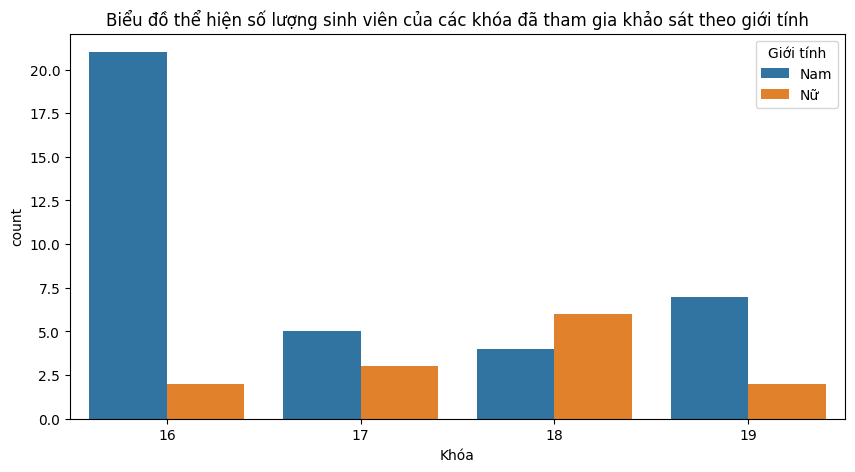

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5), dpi=100, facecolor='w', edgecolor='k')
plt.title('Biểu đồ thể hiện số lượng sinh viên của các khóa đã tham gia khảo sát theo giới tính')
sns.countplot(x='Khóa', hue='Giới tính', data=df_khaosat, ax=ax)

<a id='sec5-2'></a>
### 5.2. Trực quan hóa kết quả khảo sát

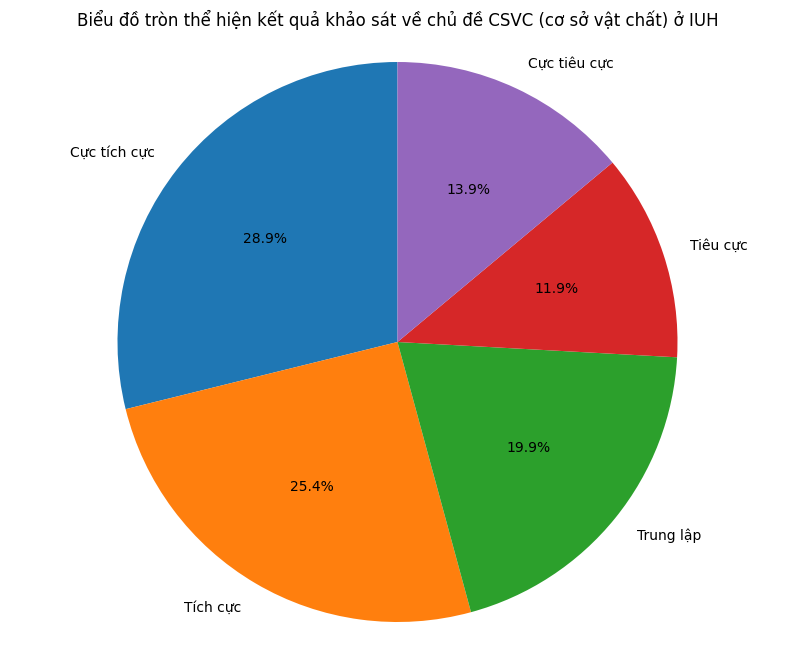

In [ ]:
data_khaosat = df_khaosat[['CSVC (1)', 'CSVC (2)', 'CSVC (3)', 'CSVC(4)', 'CSVC(5)']]
plt.figure(figsize=(10,8))
plt.title('Biểu đồ tròn thể hiện kết quả khảo sát về chủ đề CSVC (cơ sở vật chất) ở IUH')
plt.pie(data_khaosat.sum(), labels=['Cực tích cực','Tích cực', 'Trung lập', 'Tiêu cực', 'Cực tiêu cực'], autopct='%1.1f%%', startangle=90)
plt.axis('equal')
plt.show()

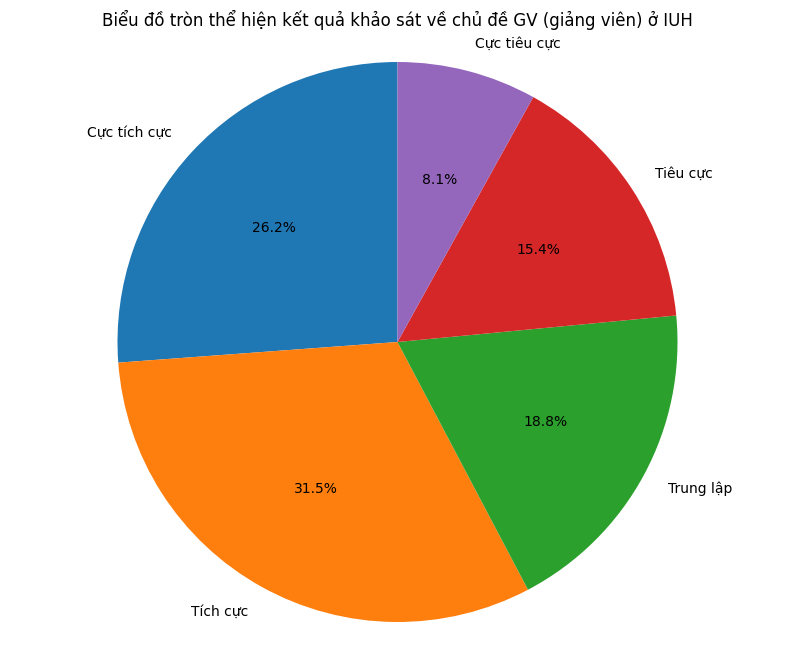

In [ ]:
data_khaosat = df_khaosat[['GV (1)', 'GV(2)', 'GV(3)', 'GV(4)', 'GV(5)']]
plt.figure(figsize=(10,8))
plt.title('Biểu đồ tròn thể hiện kết quả khảo sát về chủ đề GV (giảng viên) ở IUH')
plt.pie(data_khaosat.sum(), labels=['Cực tích cực', 'Tích cực', 'Trung lập', 'Tiêu cực','Cực tiêu cực'], autopct='%1.1f%%', startangle=90)
plt.axis('equal')
plt.show()